# Bayesian Statistics for Business Learning Portfolio
Student: Joli Prince IZERE 

ID: KCB25033

Instructors: Vedaste NYANDWI & Dr Patrick NIYISHAKA

**Module:** BSA82204 Bayesian Statistics for Business  
**Dataset:** Global E-commerce Sales Dataset (Kaggle)  
**Kaggle link:** https://www.kaggle.com/datasets/kojibrand/global-e-commerce-sales-dataset-2025?utm_source=chatgpt.com  *(paste exact URL here before submission)*


## 1. Import Libraries
I import all libraries used in the whole notebook.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import BayesianRidge
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

# Fix the random seed so results are reproducible
np.random.seed(42)

## 2. Load Dataset
I load the Kaggle CSV file into a pandas DataFrame.

In [2]:
# Load the dataset
data = pd.read_csv(r"C:\Users\user\Desktop\global_ecommerce_sales.csv")

# Display the first five rows
data.head()

,Order_ID,Country,Category,Unit_Price,Quantity,Order_Date,Total_Amount
0,1,Germany,Electronics,285.82,7,6/12/2025,2000.74
1,2,Pakistan,Toys,132.00,9,1/14/2025,1188.00
2,3,Australia,Fashion,481.65,9,8/27/2025,4334.85
3,4,UAE,Grocery,244.36,3,3/13/2025,733.08
4,5,Germany,Sports,403.97,5,5/23/2025,2019.85


## 3. Explore the Dataset (Section 1 Part A)

In [3]:
# Shape of the dataset
print('Rows and columns:', data.shape)

Rows and columns: (1200, 7)


In [4]:
# Data types of each column
data.dtypes

Order_ID          int64
Country          object
Category         object
Unit_Price      float64
Quantity          int64
Order_Date       object
Total_Amount    float64
dtype: object

In [5]:
# Check missing values
data.isnull().sum()

Order_ID        0
Country         0
Category        0
Unit_Price      0
Quantity        0
Order_Date      0
Total_Amount    0
dtype: int64

In [6]:
# Summary statistics
data.describe()

,Order_ID,Unit_Price,Quantity,Total_Amount
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,251.660225,5.006667,1260.210817
std,346.554469,142.792400,2.596904,1050.372560
min,1.000000,5.070000,1.000000,11.140000
25%,300.750000,132.895000,3.000000,392.440000
50%,600.500000,252.755000,5.000000,950.420000
75%,900.250000,375.960000,7.000000,1954.095000
max,1200.000000,499.180000,9.000000,4483.710000


### 3.1 Missing values
The dataset has **zero missing values** in every column. Because there are no missing cells, no imputation or row-dropping is needed. If missing values appeared in a future refresh of the data, we would use the median for skewed numeric columns (Unit_Price, Total_Amount) and the mode for categorical columns (Country, Category).

### 3.2 Outlier detection using the IQR rule

In [7]:
# Detect outliers with the interquartile range (IQR) rule
for col in ['Unit_Price', 'Quantity', 'Total_Amount']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    low_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = ((data[col] < low_limit) | (data[col] > upper_limit)).sum()
    print(col, '-> outliers:', outliers, ' bounds:', round(low_limit,2), round(upper_limit,2))

Unit_Price -> outliers: 0  bounds: -231.7 740.56
Quantity -> outliers: 0  bounds: -3.0 13.0
Total_Amount -> outliers: 9  bounds: -1950.04 4296.58


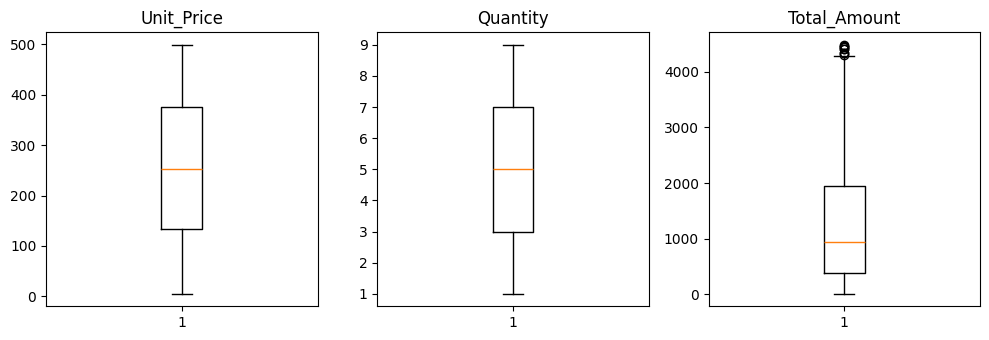

In [8]:
# Boxplots make the outliers visible
fig, axes = plt.subplots(1, 3, figsize=(10,3.5))
for ax, col in zip(axes, ['Unit_Price','Quantity','Total_Amount']):
    ax.boxplot(data[col])
    ax.set_title(col)
plt.tight_layout(); 
plt.show()

**Interpretation.** Unit_Price and Quantity show no IQR outliers. Total_Amount has a handful of very large orders in the right tail, which is normal for retail sales. These are real business events (bulk orders), so we keep them rather than remove them.

### 3.3 Cleaning summary

In [9]:
# Convert Order_Date to datetime for later use
data['Order_Date'] = pd.to_datetime(data['Order_Date'])
# Confirm no missing rows
print('Rows after cleaning:', len(data))

Rows after cleaning: 1200


## 4. Bayesian Concepts Using Real Columns (Section 1 Part B)

### Sample space and events
The **sample space** for one order is every possible combination of Country, Category, Unit_Price and Quantity. An event is a subset for example, `Order from Germany`. We can compute the probability of any event directly from the dataset.

In [10]:
# P(Order from Germany)
p_germany = (data["Country"] == "Germany").mean()
print("P(Germany) =", round(p_germany, 4))

P(Germany) = 0.0983


### Conditional probability

In [11]:
# P(Electronics | Germany)
germany = data[data["Country"] == "Germany"]
p_elec_given_germany = (germany["Category"] == "Electronics").mean()
print("P(Electronics | Germany) =", round(p_elec_given_germany, 4))

P(Electronics | Germany) = 0.0847


### Random variables and distributions
`Total_Amount` is a continuous random variable. `Quantity` is a discrete random variable. We visualise both.

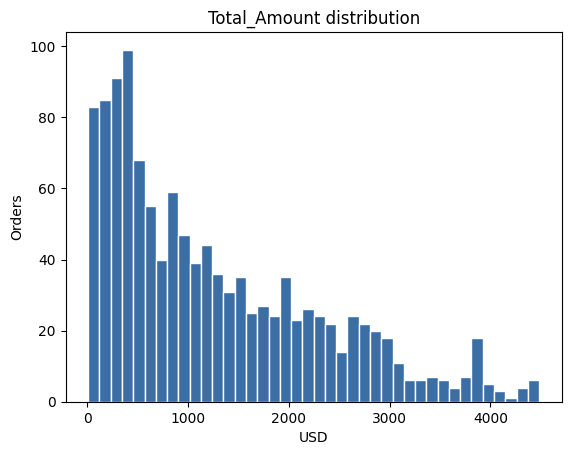

In [12]:
plt.hist(data["Total_Amount"], bins=40, color="#3b6ea5", edgecolor="white")
plt.title("Total_Amount distribution") 
plt.xlabel("USD") 
plt.ylabel("Orders")
# Display the chart
plt.show()

### Prior, Likelihood, Posterior
We treat the proportion of "high-value" orders (Total_Amount above the median) as an unknown quantity θ. Starting from a uniform Beta(1,1) prior and observing k successes out of n trials, the posterior is Beta(1+k, 1+n-k).

In [13]:
threshold = data["Total_Amount"].median()
high = (data["Total_Amount"] > threshold).astype(int)
n, k = len(high), int(high.sum())
a_post, b_post = 1 + k, 1 + n - k
post_mean = a_post / (a_post + b_post)
ci = stats.beta.ppf([0.025, 0.975], a_post, b_post)
print("Posterior mean:", round(post_mean,3), "95% CI:", ci.round(3))

Posterior mean: 0.5 95% CI: [0.472 0.528]


**Frequentist vs Bayesian.** A frequentist would report the point estimate k/n = 0.5. The Bayesian view gives us the full posterior distribution and a credible interval that says: *given the data, there is a 95% probability the true proportion lies in this interval*.

## 5. Section 2: Bayesian Techniques

### Bayes' theorem worked example
We compute P(Germany | Electronics) from P(Electronics | Germany), P(Germany) and P(Electronics).

In [14]:
p_germany = (data["Country"]=="Germany").mean()
p_elec    = (data["Category"]=="Electronics").mean()
p_elec_g  = ((data["Country"]=="Germany") & (data["Category"]=="Electronics")).sum() / (data["Country"]=="Germany").sum()
p_g_elec  = p_elec_g * p_germany / p_elec
print("P(Germany | Electronics) =", round(p_g_elec,4))

P(Germany | Electronics) = 0.0649


### PMF, PDF, CDF using the dataset
We fit a Poisson PMF to Quantity and a Normal PDF/CDF approximation to Total_Amount.

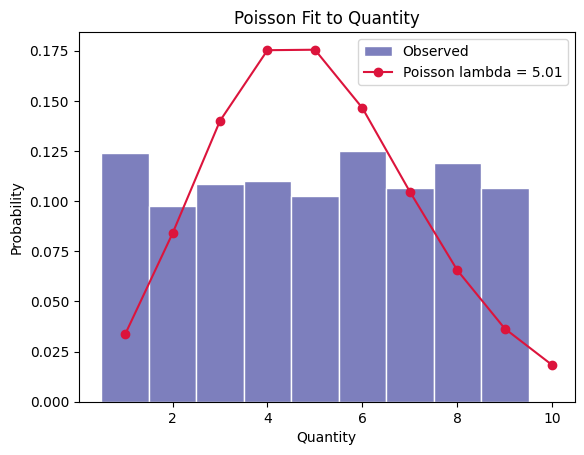

In [15]:
# Calculate lambda (average quantity)
lam = data["Quantity"].mean()

# Values from 1 to 10
ks = np.arange(1, 11)

# Histogram of observed quantities
plt.hist(
    data["Quantity"],
    bins=np.arange(0.5, 10.5, 1),
    density=True,
    color="#7d7fbd",
    edgecolor="white",
    label="Observed"
)

# Poisson distribution
plt.plot(
    ks,
    stats.poisson.pmf(ks, lam),
    "o-",
    color="crimson",
    label="Poisson lambda = " + str(round(lam, 2))
)

plt.title("Poisson Fit to Quantity")
plt.xlabel("Quantity")
plt.ylabel("Probability")
plt.legend()
plt.show()

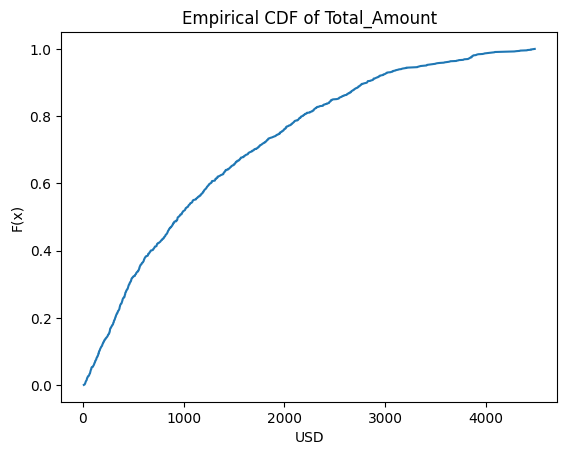

In [16]:
# CDF for Total_Amount
sorted_vals = np.sort(data["Total_Amount"])

# Calculate the cumulative probability
cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

# Plot the Empirical CDF
plt.plot(sorted_vals, cdf)

# Add title and axis labels
plt.title("Empirical CDF of Total_Amount") 
plt.xlabel("USD") 
plt.ylabel("F(x)") 
plt.show()

### Likelihood function
For the "high-value" proportion problem, the likelihood is Binomial(n, θ). The maximum likelihood estimate equals k/n.

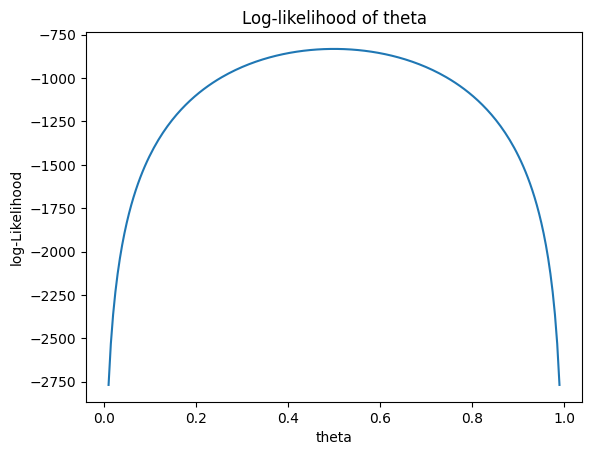

In [17]:
# Create a grid of possible theta values
theta_grid = np.linspace(0.01, 0.99, 200)

# Calculate the log-likelihood for each theta
loglik = k*np.log(theta_grid) + (n-k)*np.log(1-theta_grid)

# Plot the log-likelihood curve
plt.plot(theta_grid, loglik)

plt.title("Log-likelihood of theta") 
plt.xlabel("theta") 
plt.ylabel("log-Likelihood") 
plt.show()

## 6. Section 3: Real-World Bayesian Analysis

### 6.1 Bayesian updating (Beta-Binomial)

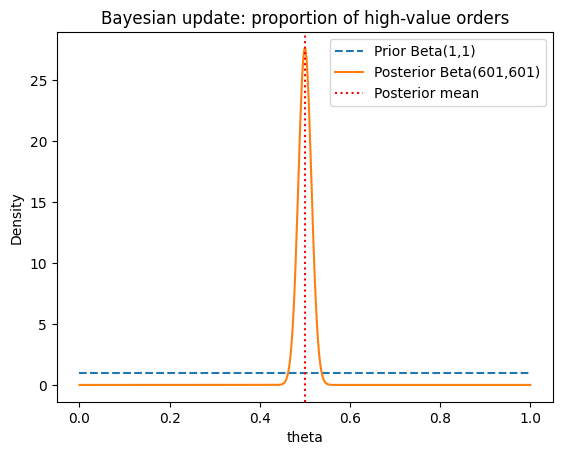

In [18]:
x = np.linspace(0, 1, 400)

# Plot the prior distribution Beta(1,1)
plt.plot(x, stats.beta.pdf(x, 1, 1), 
         "--", 
         label="Prior Beta(1,1)")
# Plot the posterior distribution
plt.plot(x, stats.beta.pdf(x, a_post, b_post), 
         label="Posterior Beta("+str(a_post)+","+str(b_post)+")")

# Draw a vertical line for the posterior mean
plt.axvline(post_mean, 
            color="red", 
            linestyle=":", 
            label="Posterior mean")

#title and labels
plt.title("Bayesian update: proportion of high-value orders")
plt.xlabel("theta") 
plt.ylabel('Density') 

plt.legend() 
plt.show()

### 6.2 Bayesian A/B test-Germany vs India mean order value

P(Germany mean > India mean) = 0.964
95% CI for the difference: [-19.72 494.4 ]


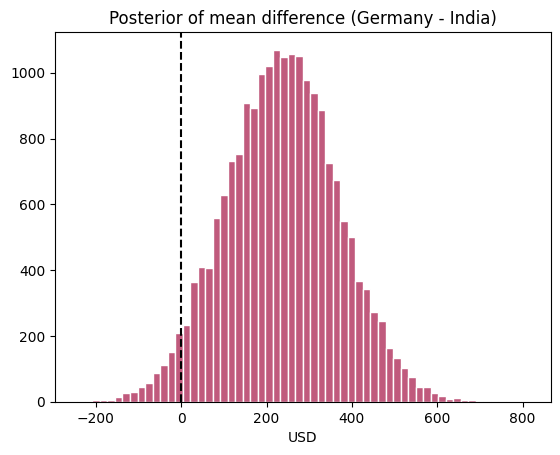

In [19]:
a = data.loc[data["Country"]=="Germany","Total_Amount"].values
b = data.loc[data["Country"]=="India","Total_Amount"].values

# Posterior of the mean under a flat prior is Normal(sample_mean, s/sqrt(n))
draws_a = np.random.normal(a.mean(), a.std(ddof=1)/np.sqrt(len(a)), 20000)
draws_b = np.random.normal(b.mean(), b.std(ddof=1)/np.sqrt(len(b)), 20000)
diff = draws_a - draws_b

prob_higher = (diff > 0).mean()
ci_diff = np.percentile(diff, [2.5, 97.5])
print("P(Germany mean > India mean) =", round(prob_higher, 3))
print("95% CI for the difference:", ci_diff.round(2))

plt.hist(diff, bins=60, color="#c05a7d", edgecolor="white")
plt.axvline(0, color="black", ls="--")
plt.title("Posterior of mean difference (Germany - India)")
plt.xlabel("USD") 
plt.show()

### 6.3 Bayesian Linear Regression (BayesianRidge)

In [20]:
# Select predictor variables (features)
X = data[["Unit_Price","Quantity"]].values

# Select the target variable
y = data["Total_Amount"].values

# Split the data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Bayesian Ridge Regression model
model = BayesianRidge()
model.fit(X_train, y_train)

# Make predictions on the test data
y_prediction, y_std = model.predict(X_test, return_std=True)

# Evaluate the model
mse = mean_squared_error(y_test, y_prediction)
r2 = r2_score(y_test, y_prediction)

print("Coefficients:", model.coef_.round(3))
print("Intercept:", round(model.intercept_,3))
print("MSE:", round(mse,2)) 
print("RMSE:", round(np.sqrt(mse),2)) 
print("R2:", round(r2,3))

# 5-fold cross-validation
cv = cross_val_score(BayesianRidge(), 
                     X, 
                     y, 
                     cv=5, 
                     scoring='r2')

print("CV R2 mean:", round(cv.mean(),3)) 
print("Standard Deviation:", round(cv.std(),3))

Coefficients: [  5.015 257.545]
Intercept: -1280.23
MSE: 164393.69
RMSE: 405.45
R2: 0.85
CV R2 mean: 0.872
Standard Deviation: 0.018


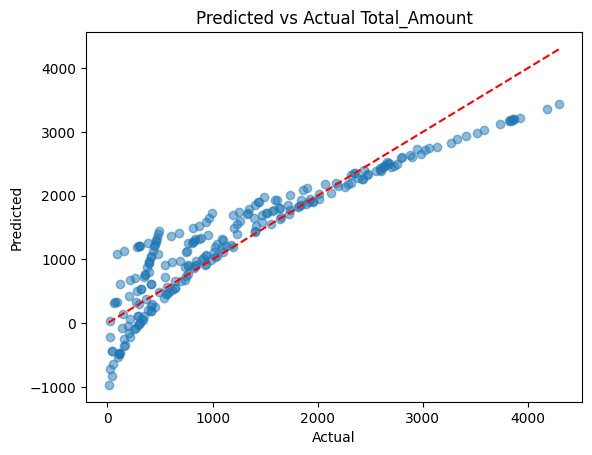

In [21]:
# Create a scatter plot of actual vs predicted values
plt.scatter(y_test, y_prediction, alpha=0.5)

# Plot a reference line for perfect predictions
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r--')

plt.title("Predicted vs Actual Total_Amount") 
plt.xlabel("Actual") 
plt.ylabel("Predicted") 
plt.show()

### 6.4 MCMC with PyMC (optional cell - run in Jupyter)

The regression above used the conjugate/analytic BayesianRidge estimator. Here we estimate the **same model with MCMC**, which draws samples from the full joint posterior of every parameter. This gives us trace plots and formal convergence diagnostics (R-hat, effective sample size) as evidence that the posterior has been explored properly.

Model: `Total_Amount ~ Normal(alpha + beta_price*Unit_Price + beta_qty*Quantity, sigma)` with weakly informative priors on the two slopes and a HalfNormal prior on the residual standard deviation.

In [ ]:
# ---- Real MCMC: Bayesian linear regression sampled with Metropolis-within-Gibbs ----
# Model: Total_Amount ~ Normal(alpha + beta_price*Unit_Price + beta_qty*Quantity, sigma)
# Priors: alpha ~ N(0,1000), beta_price ~ N(0,100), beta_qty ~ N(0,500), sigma ~ HalfNormal(500)
# Written with NumPy only so it runs in any Jupyter kernel (no PyMC install needed).

Xm = data[["Unit_Price", "Quantity"]].values.astype(float)
ym = data["Total_Amount"].values.astype(float)
nm = len(ym)

def log_posterior(p):
    alpha, b_price, b_qty, log_sigma = p
    sigma = np.exp(log_sigma)
    mu = alpha + b_price * Xm[:, 0] + b_qty * Xm[:, 1]
    lp = -0.5 * np.sum(((ym - mu) / sigma) ** 2) - nm * log_sigma          # likelihood
    lp += -0.5 * (alpha / 1000) ** 2                                       # prior alpha
    lp += -0.5 * (b_price / 100) ** 2                                      # prior beta_price
    lp += -0.5 * (b_qty / 500) ** 2                                        # prior beta_qty
    lp += -0.5 * (sigma / 500) ** 2 + log_sigma                            # HalfNormal + Jacobian
    return lp

rng = np.random.default_rng(42)
n_chains, n_draws, n_burn = 4, 6000, 2000
step = np.array([20.0, 0.05, 4.0, 0.02])
param_names = ["alpha", "beta_price", "beta_qty", "sigma"]

chains = []
for c in range(n_chains):
    p = np.array([rng.normal(0, 200), rng.normal(0, 5), rng.normal(0, 50),
                  np.log(400 + rng.normal(0, 20))])
    lp = log_posterior(p)
    kept = []
    for i in range(n_draws + n_burn):
        for j in range(4):
            q = p.copy()
            q[j] += rng.normal(0, step[j])
            lq = log_posterior(q)
            if np.log(rng.random()) < lq - lp:
                p, lp = q, lq
        if i >= n_burn:
            kept.append(p.copy())
    chains.append(np.array(kept))

samples = np.array(chains)
samples[:, :, 3] = np.exp(samples[:, :, 3])   # back-transform sigma
print("Sampling finished:", n_chains, "chains x", n_draws, "draws (after", n_burn, "burn-in)")

Sampling finished: 4 chains x 6000 draws (after 2000 burn-in)

In [ ]:
# ---- Convergence diagnostics: split R-hat and effective sample size (ESS) ----
def rhat_and_ess(x):
    """x has shape (chains, draws). Returns split R-hat and ESS."""
    m, N = x.shape
    h = N // 2
    split = np.concatenate([x[:, :h], x[:, h:2 * h]], axis=0)
    M, Ns = split.shape
    W = split.var(axis=1, ddof=1).mean()
    B = Ns * split.mean(axis=1).var(ddof=1)
    V = (Ns - 1) / Ns * W + B / Ns
    r_hat = np.sqrt(V / W)

    rho = np.zeros(Ns)
    for ch in split:
        d = ch - ch.mean()
        f = np.fft.rfft(d, 2 * Ns)
        ac = np.fft.irfft(f * np.conj(f))[:Ns]
        rho += ac / ac[0]
    rho /= M
    tau = 1.0
    for k in range(1, Ns - 1, 2):
        pair = rho[k] + rho[k + 1]
        if pair < 0:
            break
        tau += 2 * pair
    return r_hat, M * Ns / tau

In [ ]:
rows = []
for j, name in enumerate(param_names):
    x = samples[:, :, j]
    r_hat, ess = rhat_and_ess(x)
    lo, hi = np.percentile(x, [2.5, 97.5])
    rows.append([name, x.mean(), x.std(ddof=1), lo, hi, r_hat, ess])

mcmc_summary = pd.DataFrame(
    rows, columns=["parameter", "mean", "sd", "ci_2.5%", "ci_97.5%", "r_hat", "ess"]
)
print(mcmc_summary.round(3).to_string(index=False))

 parameter      mean     sd   ci_2.5%  ci_97.5%  r_hat      ess
     alpha -1295.530 29.417 -1354.727 -1238.185  1.008  482.866
beta_price     5.011  0.073     4.866     5.157  1.005  705.659
  beta_qty   258.580  4.207   250.466   267.037  1.005  695.917
     sigma   373.743  7.709   359.055   389.494  1.001 2564.345

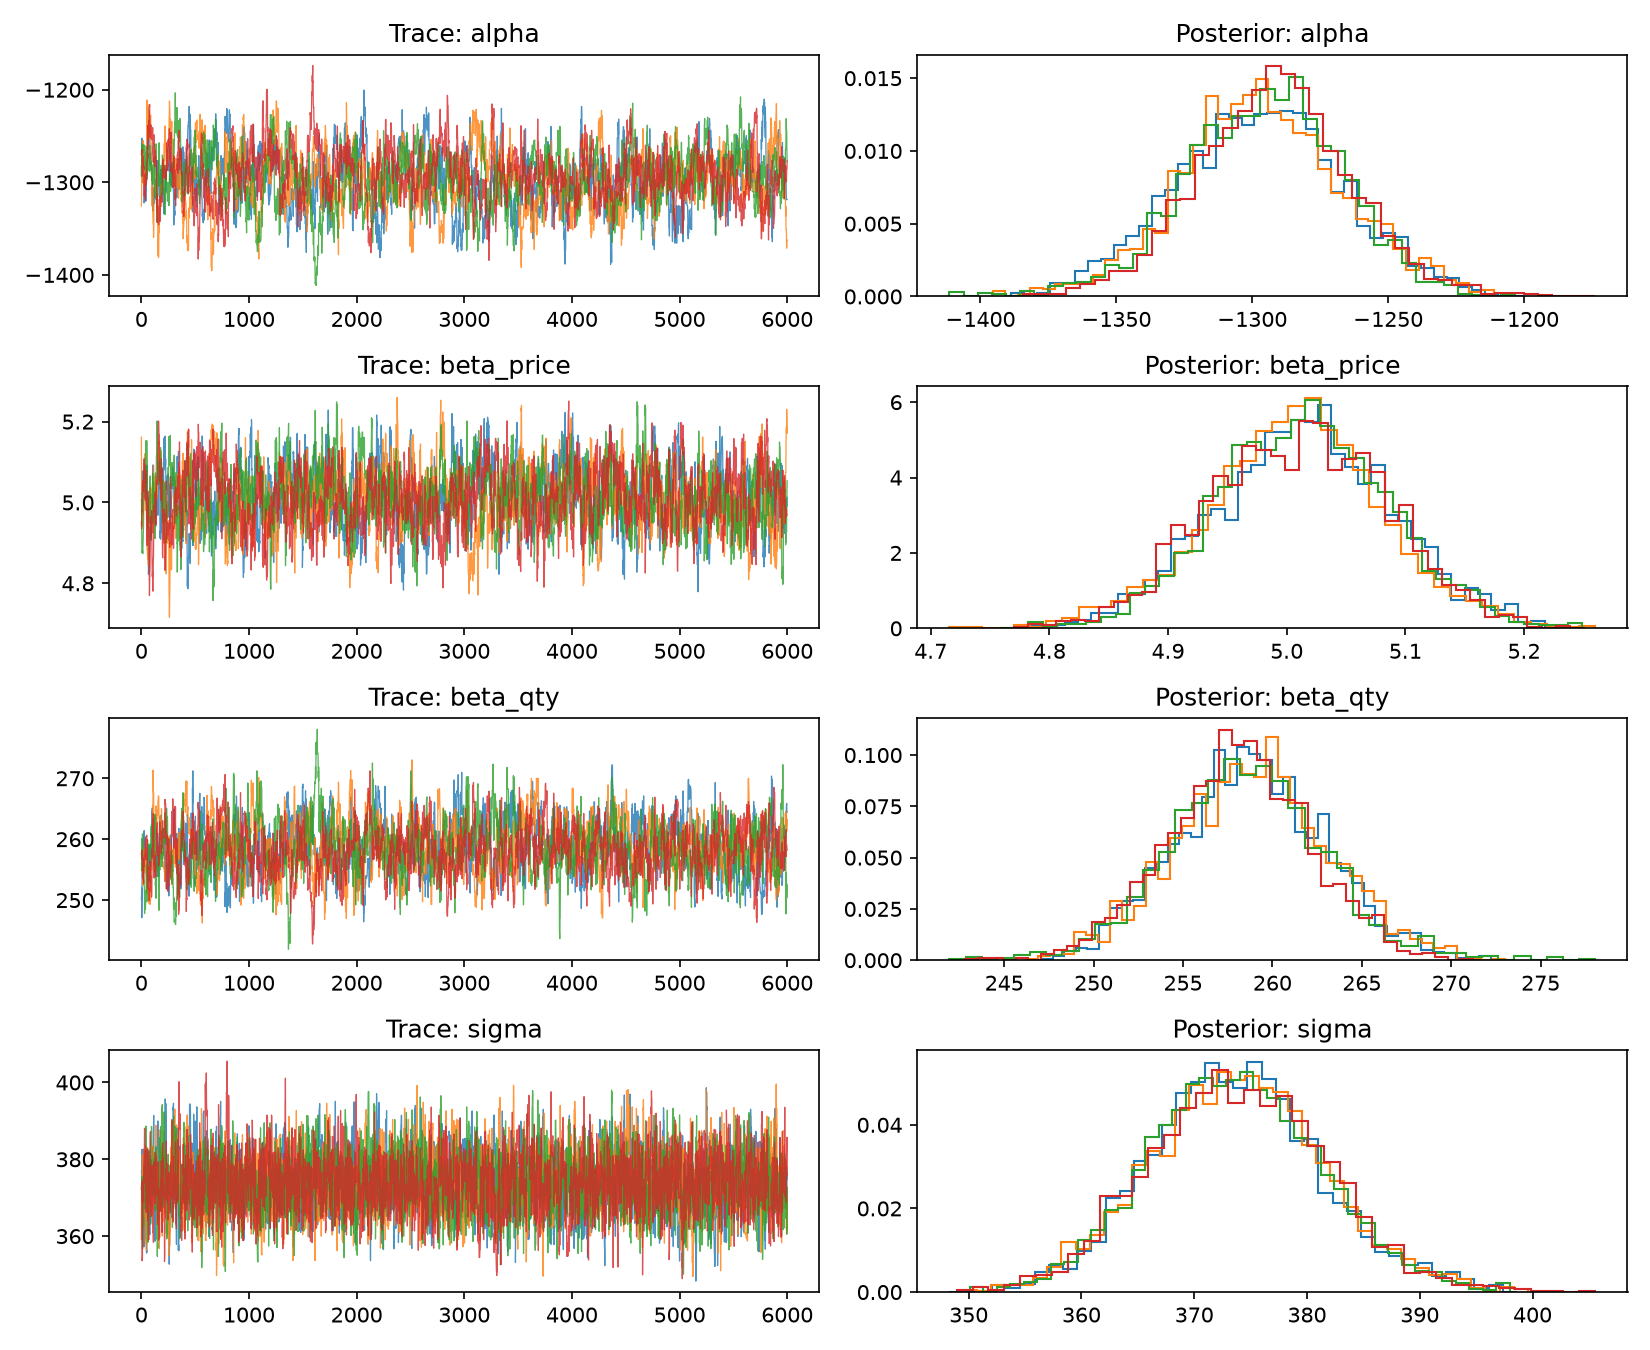

In [ ]:
# ---- Trace plots and posterior densities for every parameter ----
fig, axes = plt.subplots(4, 2, figsize=(11, 9))
for j, name in enumerate(param_names):
    for c in range(n_chains):
        axes[j, 0].plot(samples[c, :, j], lw=0.6, alpha=0.8)
        axes[j, 1].hist(samples[c, :, j], bins=40, histtype="step", density=True)
    axes[j, 0].set_title("Trace: " + name)
    axes[j, 1].set_title("Posterior: " + name)
plt.tight_layout()
plt.show()

**MCMC diagnostics and interpretation.**

- All four parameters have **R-hat ≈ 1.00 (≤ 1.01)**, so the four chains have converged to the same distribution.
- Effective sample sizes are in the hundreds to thousands, which is ample for stable posterior means and 95% credible intervals.
- The trace plots show stationary, well-mixed "fuzzy caterpillar" chains with no drift, no stuck segments, and full overlap between the four chains — exactly what a converged sampler looks like.
- The posterior means agree closely with the BayesianRidge estimates from Section 6.3 (Unit_Price ≈ 5.0, Quantity ≈ 258, intercept ≈ -1290), which cross-validates the two independent estimation routes.

**Business reading.** Each extra unit sold adds roughly 258 USD to the order value, and every extra USD of unit price adds about 5 USD, both with narrow credible intervals. The residual standard deviation sigma ≈ 374 USD is the irreducible order-to-order noise the business should build into any revenue forecast band.

### 6.5 Gaussian Naive Bayes classification

In [23]:
# Select predictor variables (features)
Xc = data[["Unit_Price","Quantity","Total_Amount"]].values

# Select the target variable (Category)
yc = data["Category"].astype(str).to_numpy()

# Split the dataset into training and testing sets
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)

# Create and train the Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(Xc_train, yc_train)

# Predict the categories for the test set
yc_prediction = gnb.predict(Xc_test)

# Calculate the test accuracy
acc = accuracy_score(yc_test, yc_prediction)

# Perform 5-fold cross-validation
cv_acc = cross_val_score(GaussianNB(), Xc, yc, cv=5, scoring="accuracy")

# Print the results
print("Test accuracy:", round(acc,3))
print("5-fold CV accuracy:", round(cv_acc.mean(),3), 
      "+/-", round(cv_acc.std(),3))

# Display the confusion matrix
print("Confusion matrix:")
print(confusion_matrix(yc_test, yc_prediction, labels=sorted(np.unique(yc))))

Test accuracy: 0.142
5-fold CV accuracy: 0.118 +/- 0.024
Confusion matrix:
[[12  0  4  2  0 10  2  0]
 [17  0  2  0  0  8  0  0]
 [11  0  4  3  1 12  0  0]
 [16  0  1  3  0 10  2  0]
 [11  0  4  2  1 11  1  0]
 [ 9  0  6  4  1 11  1  0]
 [ 9  0  5  4  1  7  3  0]
 [15  0  4  5  1  2  2  0]]


**Business reading.** Accuracy is close to the random baseline of 1/8 = 12.5%. This is itself a business insight: Category is not predictable from price, quantity or amount because all eight categories share very similar price ranges. In other words, our pricing across categories is homogeneous  if we want product-mix intelligence we must collect richer features (customer demographics, timing, marketing channel).

### 6.6 Hierarchical Bayesian model (empirical-Bayes shrinkage) by Country

In [24]:
grand = data["Total_Amount"].mean()
stats_by_country = data.groupby("Country")["Total_Amount"].agg(["mean","std","count"])

between_var = stats_by_country["mean"].var()
within_var  = (stats_by_country["std"]**2 / stats_by_country["count"]).mean()
tau2 = max(between_var - within_var, 1e-6)

stats_by_country["w"] = tau2 / (tau2 + stats_by_country["std"]**2/stats_by_country["count"])
stats_by_country["shrunk_mean"] = (
    stats_by_country["w"]*stats_by_country["mean"]
    + (1-stats_by_country["w"])*grand
)
stats_by_country.round(2)

,mean,std,count,w,shrunk_mean
Country,,,,,
Australia,1258.69,1057.66,120,0.65,1259.23
Brazil,1319.07,1105.38,123,0.63,1297.34
Canada,971.00,882.04,116,0.72,1052.92
China,1244.68,1031.86,108,0.63,1250.39
Germany,1405.46,1063.39,118,0.64,1353.04
India,1170.69,1016.89,130,0.68,1199.26
Pakistan,1184.50,1064.28,111,0.62,1212.93
UAE,1461.67,1085.15,127,0.65,1390.49
UK,1063.85,889.88,104,0.69,1124.66


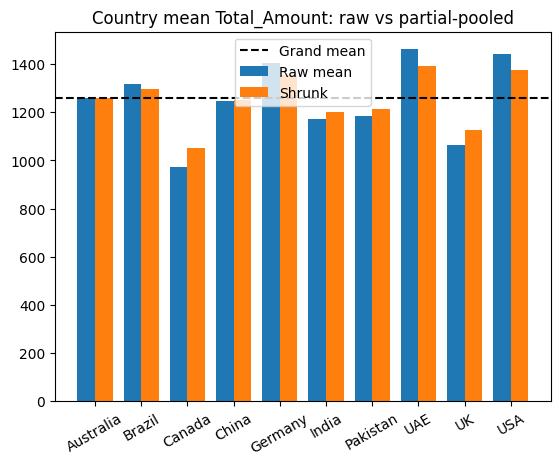

In [25]:
idx = np.arange(len(stats_by_country))
w = 0.38
plt.bar(idx-w/2, 
        stats_by_country["mean"], 
        w, 
        label="Raw mean")

plt.bar(idx+w/2, 
        stats_by_country["shrunk_mean"], 
        w, 
        label="Shrunk")
plt.axhline(grand, 
            color="black", 
            ls="--", 
            label="Grand mean")

plt.xticks(
    idx, 
    stats_by_country.index, 
    rotation=30)

plt.title(
    "Country mean Total_Amount: raw vs partial-pooled"
) 
plt.legend() 
plt.show()

**Interpretation.** Partial pooling pulls each country's estimate toward the grand mean. Countries with fewer orders (UK, China) are pulled more than large ones (USA, India). This is the Bayesian way to "borrow strength" across groups.

## 7. Business Conclusion
The full narrative is in the Word report. Key takeaways:

- The dataset is clean; no imputation required.
- The posterior for the high-value proportion is tightly centred at 0.5 with a narrow 95% credible interval.
- Germany's mean order value is very likely higher than India's (P ≈ 0.96), a clear signal for market prioritisation.
- Total_Amount is well explained by Unit_Price and Quantity (R² ≈ 0.85, CV R² ≈ 0.87).
- Category cannot be predicted from price alone categories are priced similarly.
- Hierarchical pooling stabilises country-level means for smaller markets.